# Annotation → Taxonomy → Ontology: what each layer of structure buys you in retrieval

**A controlled study on NFCorpus (biomedical IR) with MeSH, GLiNER, GTE embeddings and Qwen.**

---

This notebook answers a question every search/AI team eventually faces:

> *We can tag our content with entities. We can organise those entities into a hierarchy.
> We can connect them with relationships. **Which of these actually moves retrieval quality —
> and is it worth the cost?***

We make the three layers concrete and measurable:

| Layer | What it adds | Made real here by |
|------|--------------|-------------------|
| **Annotation** | spans of text tagged with a *type* (flat) | **GLiNER** zero-shot NER → linked to **MeSH** concepts |
| **Taxonomy** | an *is-a* hierarchy over those types | **MeSH** tree numbers (42k is-a edges) |
| **Ontology** | *relationships & rules* between types | **MeSH** pharmacological-action + see-also relations |

We then measure **Recall@10** and **nDCG@10** for a ladder of retrievers — lexical, semantic,
structure-aware, and LLM-driven — holding the corpus, queries and metric fixed so every
difference is attributable to the representation, not a confound.

## 1 · Setup

Everything below loads **precomputed checkpoints** produced by the staged pipeline in `src/`
(`build_mesh.py`, `prep.py`, `m_baselines.py`, `entities.py`, `m_structure.py`,
`m_dense_expand.py`, `m_llm.py`, `aggregate.py`). This keeps the notebook fast and reproducible —
the heavy GPU work (GTE encoding, GLiNER NER, Qwen generation) ran once and was cached.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))
import pandas as pd, numpy as np
from IPython.display import Image, display, Markdown
from common import load_ckpt, load_json, FIG, CKPT
pd.set_option("display.max_colwidth", 60)
print("checkpoints available:", len(list(CKPT.glob("*.pkl"))), "pkl +",
      len(list(CKPT.glob("*.json"))), "json")

checkpoints available: 87 pkl + 4 json


## 2 · The dataset — NFCorpus

**NFCorpus** is a biomedical information-retrieval benchmark: real PubMed abstracts as documents,
and natural-language health questions (sourced from NutritionFacts.org) as queries, with graded
relevance judgments. It is the ideal testbed for this study because its entities map cleanly onto
**MeSH**, giving us a ready-made taxonomy *and* ontology.

In [2]:
stats = load_json("eda_stats")
display(Markdown(f'''
| metric | value |
|---|---|
| documents (PubMed abstracts) | **{stats["n_docs"]:,}** |
| test queries | **{stats["n_test_queries"]}** |
| relevance judgments | **{stats["n_judgments"]:,}** |
| mean document length | {stats["doc_len_mean"]:.0f} words |
| mean query length | **{stats["query_len_mean"]:.1f} words** (very short!) |
| relevant docs / query (mean / median) | {stats["rel_per_query_mean"]:.0f} / {stats["rel_per_query_median"]:.0f} |
'''))


| metric | value |
|---|---|
| documents (PubMed abstracts) | **3,633** |
| test queries | **323** |
| relevance judgments | **12,334** |
| mean document length | 234 words |
| mean query length | **3.3 words** (very short!) |
| relevant docs / query (mean / median) | 38 / 16 |


The decisive feature for this study: **queries are ~3 words long.** Short queries starve a
semantic model of context — exactly the regime where injecting external structure (a taxonomy or
ontology) *should* pay off. We will see that *how* you inject it matters enormously.

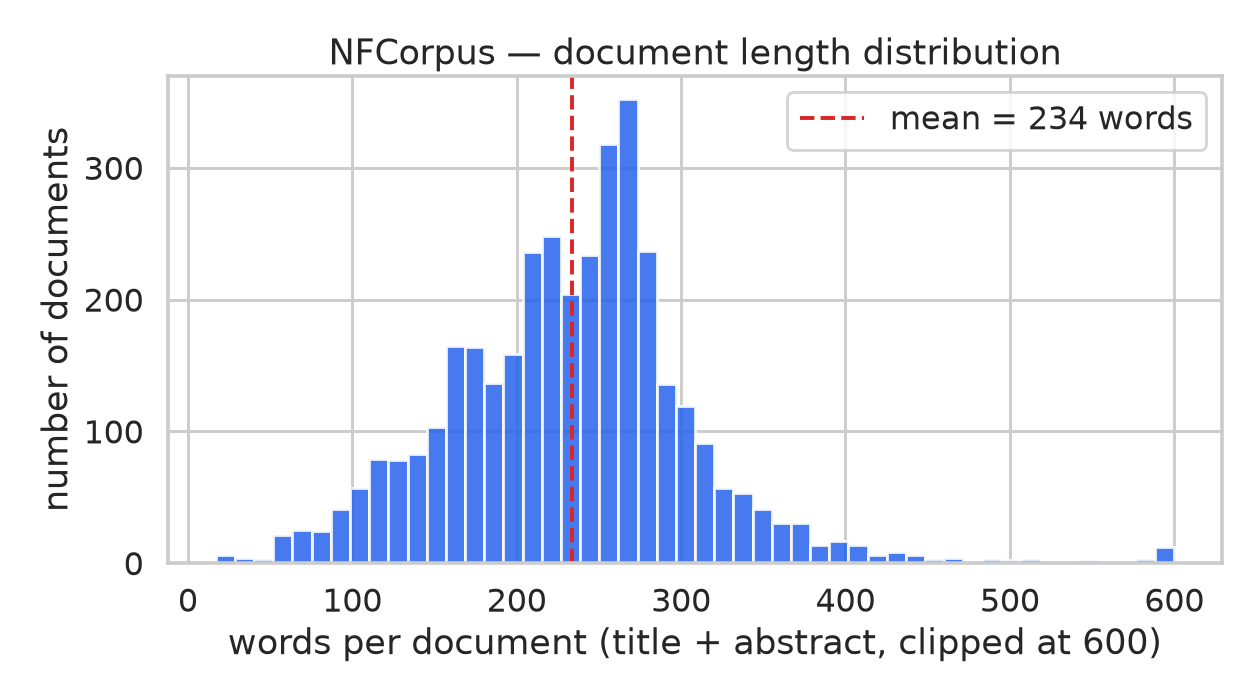

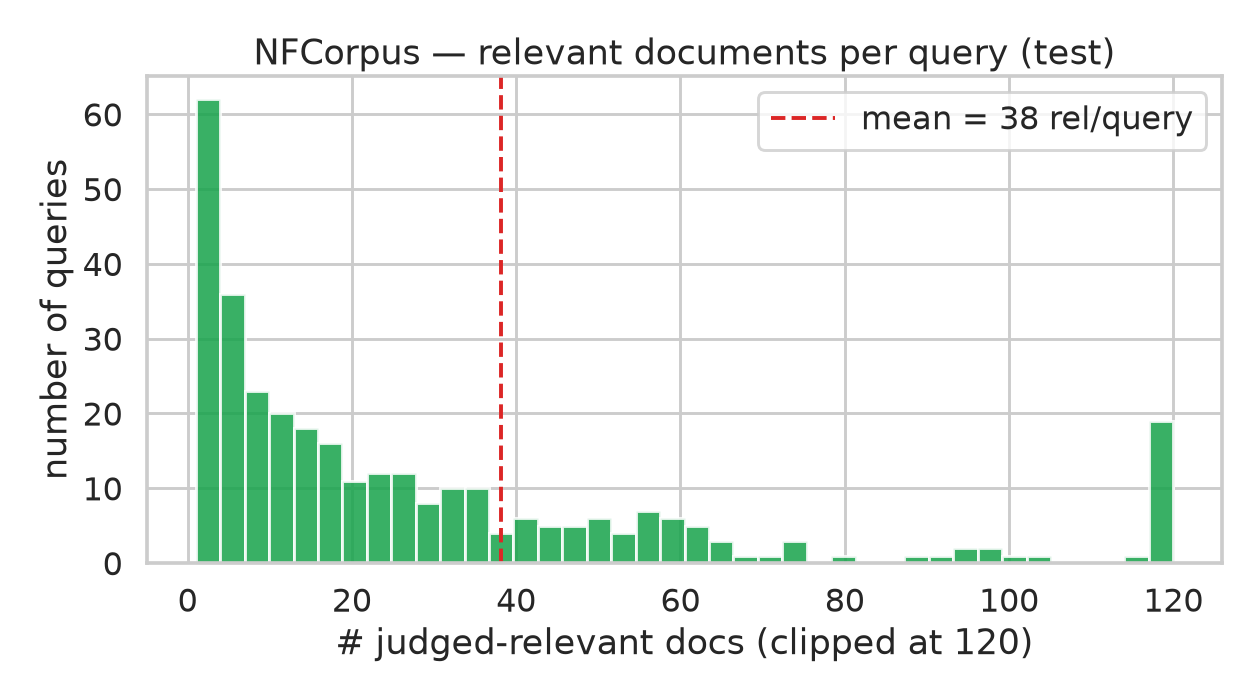

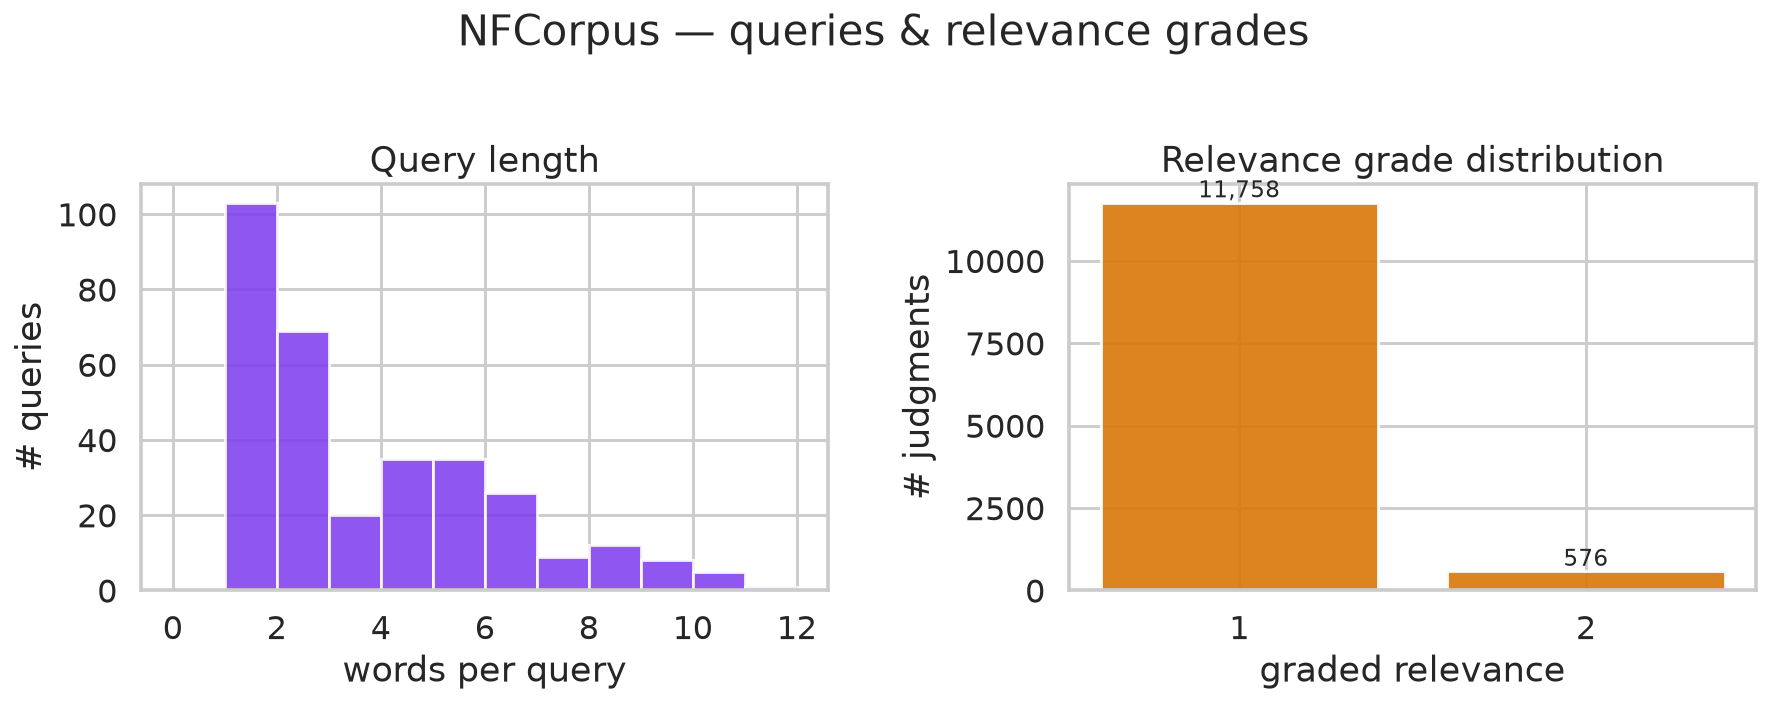

In [3]:
for f in ["eda_doc_len.png", "eda_rel_per_q.png", "eda_query_grade.png"]:
    display(Image(str(FIG / f)))

## 3 · The knowledge layers, made concrete in MeSH

**The one-analogy version — organising a pharmacy.**

- **Annotation** = putting a *label* on each box: "this is a drug," "this is a disease." Useful,
  but the labels don't know about each other.
- **Taxonomy** = the *shelving*: every drug sits under a broader category —
  *atorvastatin → statin → cholesterol-lowering drug → drug* — so you can step up a shelf to find
  related things. It is the **nouns, filed into a hierarchy**.
- **Ontology** = the *wiring between shelves*: *statins **lower** cholesterol*, *this drug **treats**
  that disease*. It is the **nouns plus the verbs** — how things act on each other.

MeSH (Medical Subject Headings) is the NLM's controlled vocabulary — it gives us all three layers
for free. We parsed the full 2025 descriptor set into a retrieval-ready index.

In [4]:
mesh = load_ckpt("mesh_index")
print(f"descriptors (concepts):        {len(mesh['ui2name']):,}")
print(f"surface forms (synonyms):      {len(mesh['name2ui']):,}")
print(f"is-a edges (TAXONOMY):         {sum(len(v) for v in mesh['parent_ui'].values()):,}")
print(f"descriptors w/ relations (ONTOLOGY): {len(mesh['relations']):,}")

descriptors (concepts):        30,956
surface forms (synonyms):      244,211
is-a edges (TAXONOMY):         42,287
descriptors w/ relations (ONTOLOGY): 8,552


### A single query through every layer

The same query, lifted rung by rung — from a flat NER tag to a connected ontology neighbourhood
to an LLM expansion. This is the whole thesis in one example.

In [5]:
ex = load_ckpt("worked_example")
print("QUERY:", ex["query_text"], "\n")
print("① ANNOTATION — GLiNER NER spans (flat type tags):")
for span, label, score in ex["ner_spans"]:
    print(f"     '{span}'  ->  [{label}]  ({score:.2f})")
print("\n   linked to MeSH concepts:")
for ui, name in ex["concepts"]:
    print(f"     {ui}  {name}")
print("\n② TAXONOMY — is-a ancestors (climbing the tree):")
for concept, chain in ex["taxonomy"].items():
    print(f"     {concept}  ->  " + "  ->  ".join(chain))
print("\n③ ONTOLOGY — non-is-a relations (pharmacological-action / see-also):")
for concept, rels in ex.get("ontology", {}).items():
    print(f"     {concept}  ~  " + ", ".join(rels))
if "llm_onto" in ex:
    print("\n④ LLM EXPANSION (Qwen, ontology-grounded):")
    print("    ", ex["llm_onto"][:300])

QUERY: Do Cholesterol Statin Drugs Cause Breast Cancer? 

① ANNOTATION — GLiNER NER spans (flat type tags):
     'Cholesterol Statin Drugs'  ->  [drug]  (0.99)
     'Breast Cancer'  ->  [cancer]  (0.94)

   linked to MeSH concepts:
     D001943  Breast Neoplasms

② TAXONOMY — is-a ancestors (climbing the tree):
     Breast Neoplasms  ->  Breast Diseases  ->  Skin Diseases  ->  Skin and Connective Tissue Diseases

③ ONTOLOGY — non-is-a relations (pharmacological-action / see-also):
     Breast Neoplasms  ~  Breast Cancer Lymphedema

④ LLM EXPANSION (Qwen, ontology-grounded):
     Cholesterol, Statins, Breast Cancer, Lymphedema, Neoplasms, Breast Diseases, Breast Neoplasms, Lipids, Cardiovascular Disease, Adverse Effects, Drug Therapy, Oncology, Metabolism, Hormones, Epidemiology, Risk Factors, Treatment Outcome


### What each layer *looks* like

Before the numbers, the intuition. **Annotation** tags spans with a flat type — the tags float
free, with no links between them. **Taxonomy** organises those types into an *is-a* hierarchy —
every node has a parent, so you can generalise upward. **Ontology** adds typed, *non-hierarchical*
relationships on top — which is what lets it support reasoning and ground an LLM.

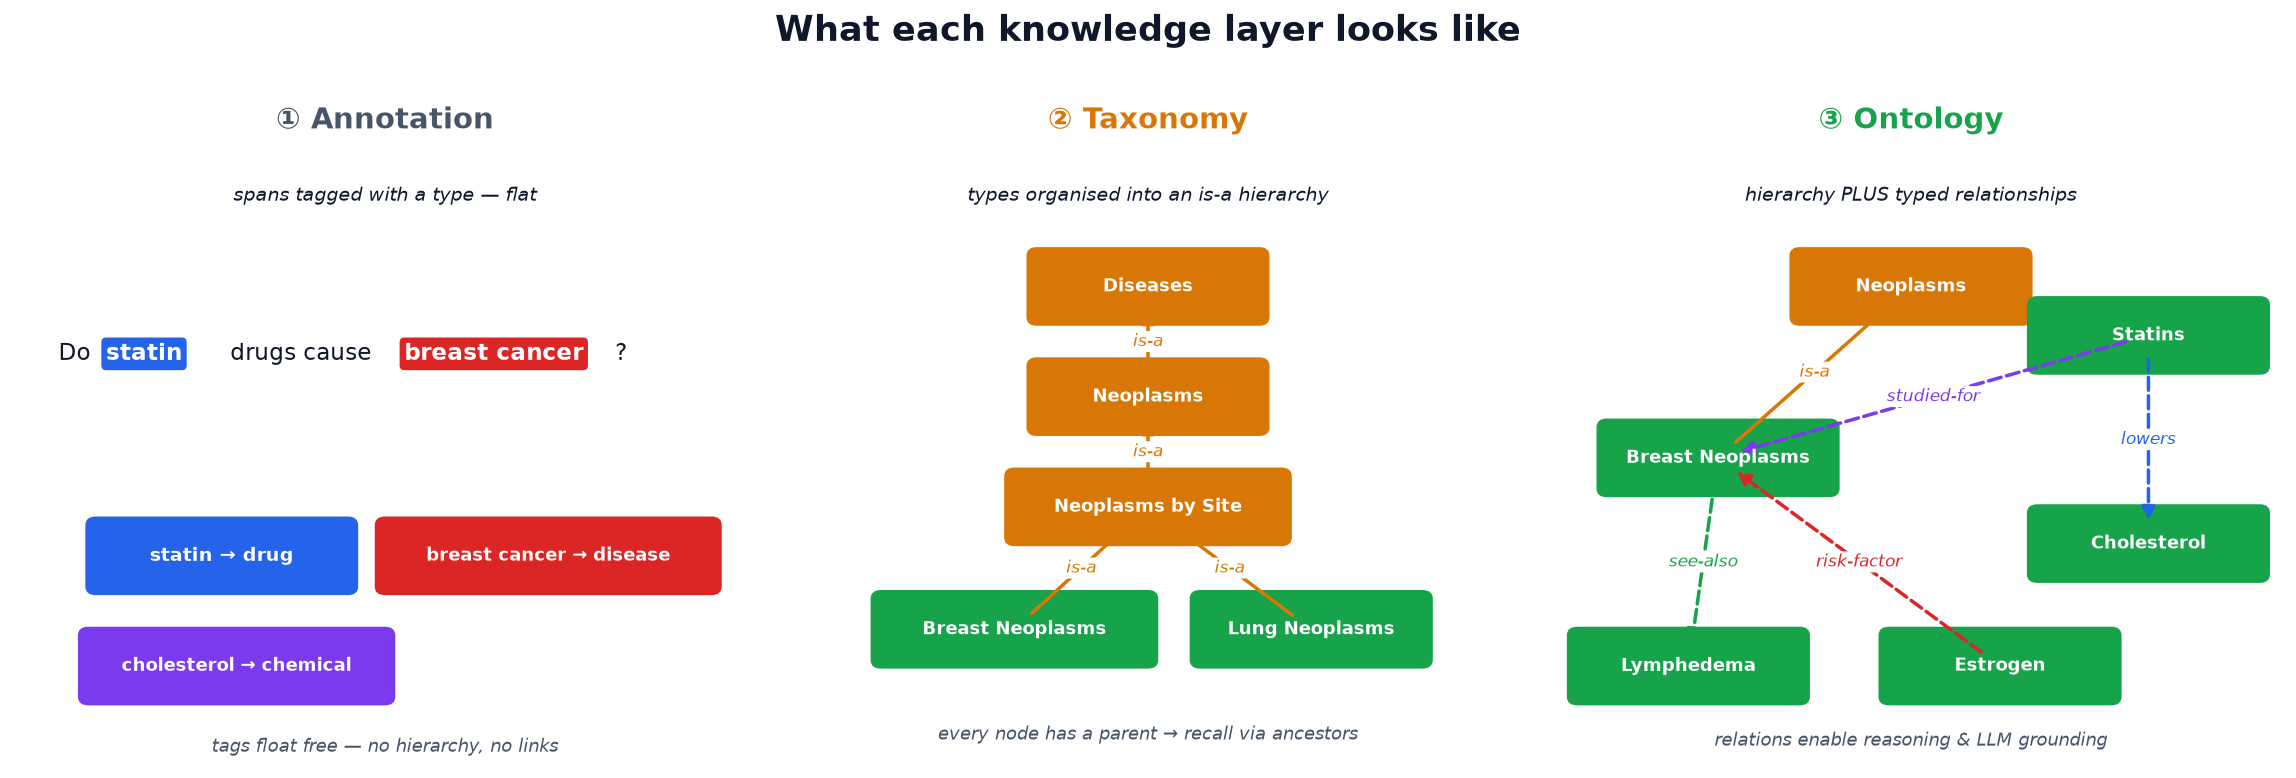

In [6]:
display(Image(str(FIG / "fig_layers_schematic.png")))

#### The taxonomy we actually identified

A crucial clarification, since there is **no subject-matter expert in this loop**: we did **not**
induce the taxonomy bottom-up from the corpus. The hierarchy *is* MeSH — hand-curated by NLM
experts. What is automated here is **(1) linking** each NER span to a MeSH node (bottom-up) and
**(2) climbing** the is-a edges from those nodes upward. The figure shows the real slice of the
MeSH *Diseases* branch our corpus activates: **green** = concepts linked from documents (with the
doc count), **grey** = is-a ancestors added by the climb, **black** = the category root.

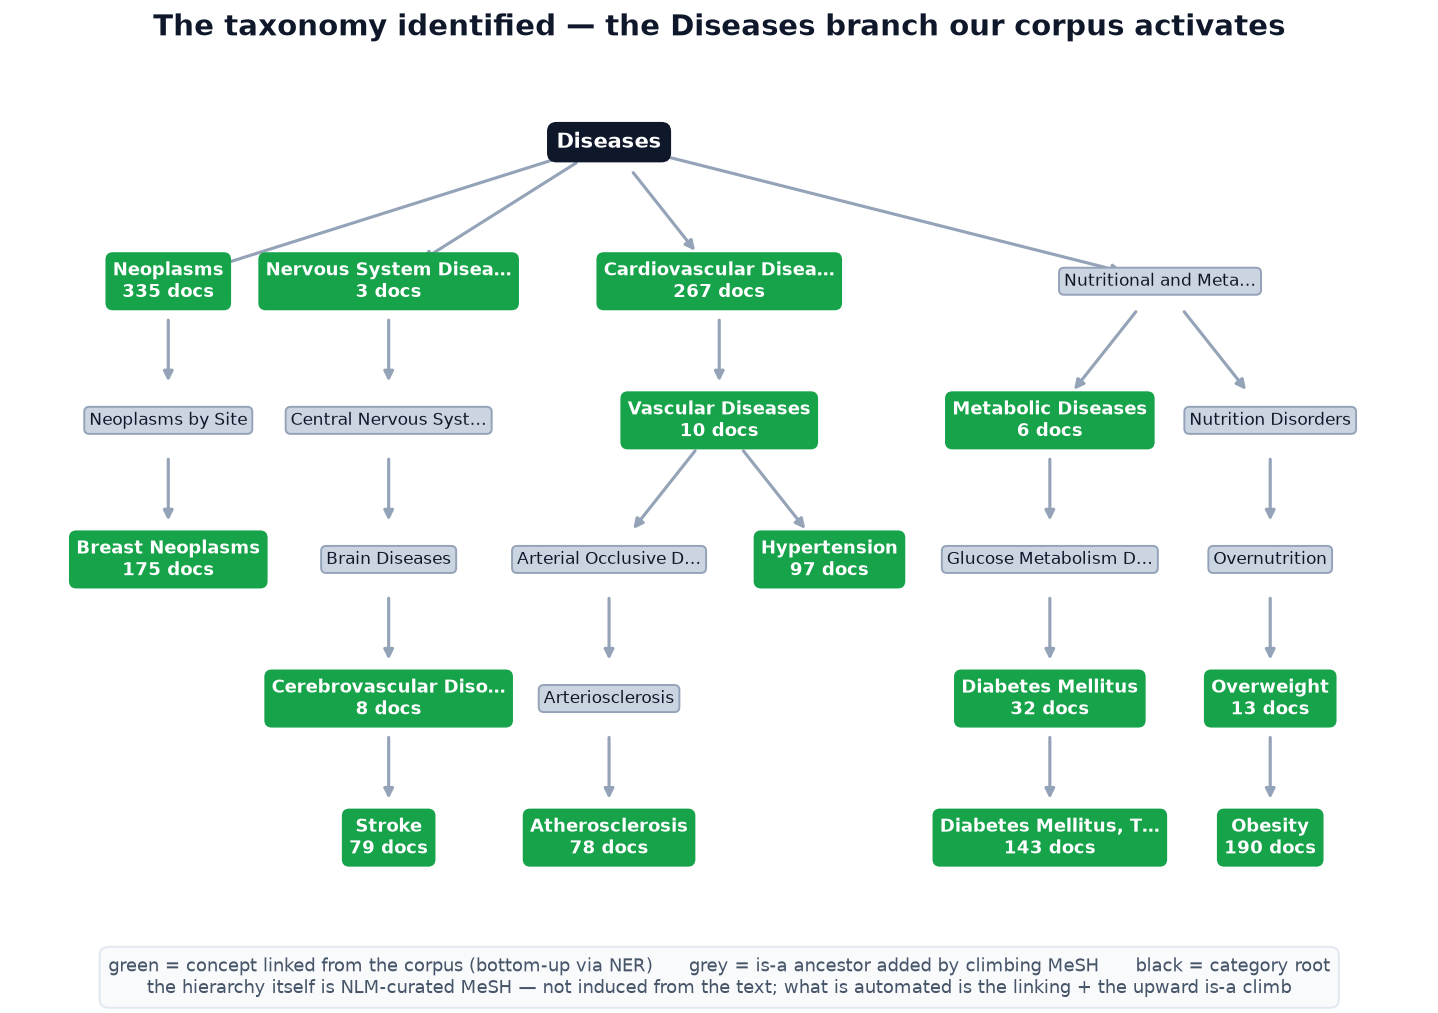

In [7]:
display(Image(str(FIG / "fig_taxonomy_identified.png")))

#### …and the ontology around one concept

The ontology adds what a tree cannot express: typed cross-links (MeSH pharmacological-action,
see-also). **Solid amber** edges are is-a (taxonomy); **dashed green** edges are relations
(ontology only) — those dashed links are exactly what a taxonomy is missing and what grounds an
LLM's reasoning.

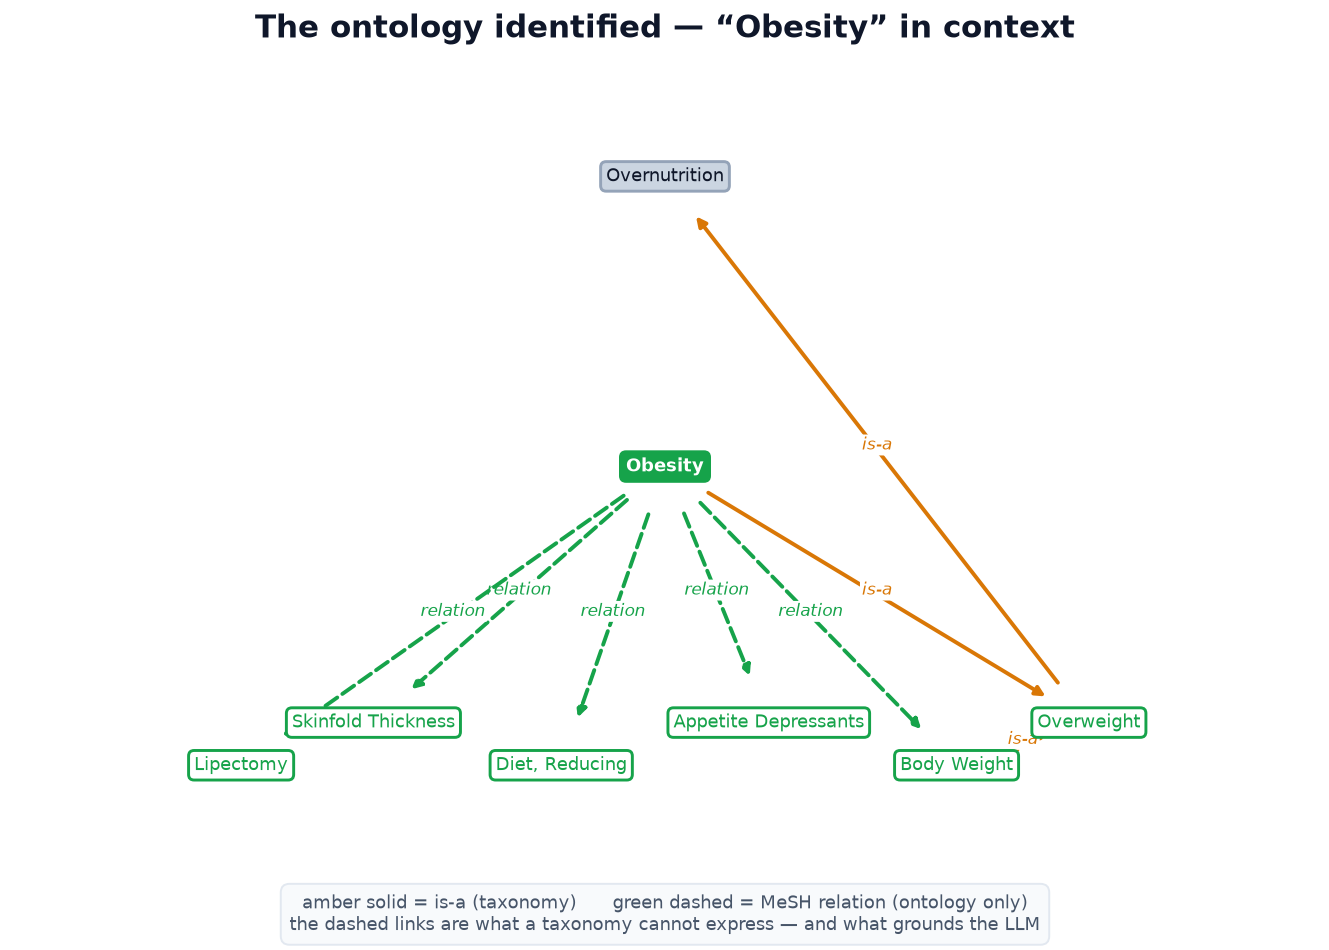

In [8]:
display(Image(str(FIG / "fig_ontology_identified.png")))

## 4 · The retrieval methods

A controlled ladder. Same 3,633 docs, same 323 queries, same metric — only the representation changes.

| # | Method | Representation | Layer |
|---|--------|----------------|-------|
| M0 | **BM25** | raw lexical overlap | — |
| M1 | **Dense (GTE)** | 1024-d semantic embeddings | — |
| M2 | **Annotation** | overlap of linked MeSH concepts (flat) | Annotation |
| M3 | **Taxonomy** | concepts + is-a ancestors | Taxonomy |
| M4 | **Ontology** | concepts + ancestors + relations | Ontology |
| — | **Dense + {Ann/Tax/Onto}** | structure injected as query-text expansion | combined |
| — | **LLM-QE / LLM-QE+Onto** | Qwen expands the query (free / ontology-grounded) | LLM |
| M5 | **Hybrid** | rank-fusion of semantics + structure | combined |

- **Standalone structure (M2–M4)** uses BM25 over bags of MeSH concept IDs — a sparse search over
  the *structured index*. It isolates the pure contribution of each knowledge layer.
- **Dense + structure** and **LLM-QE** inject structure into the *semantic* retriever via query
  expansion — the production-realistic way to combine them.

## 5 · Results

> **Headline:** the best *overall* ranker is the production hybrid — a strong semantic
> embedder enriched by **ontology-grounded LLM query expansion**. It wins nDCG@5, nDCG@10,
> nDCG@20, Recall@20, Recall@100 and P@10, and ties the dense baseline on Recall@10.
> Plain structure injection, by contrast, does **not** beat a strong embedder — *how* you
> inject structure is what determines ROI.

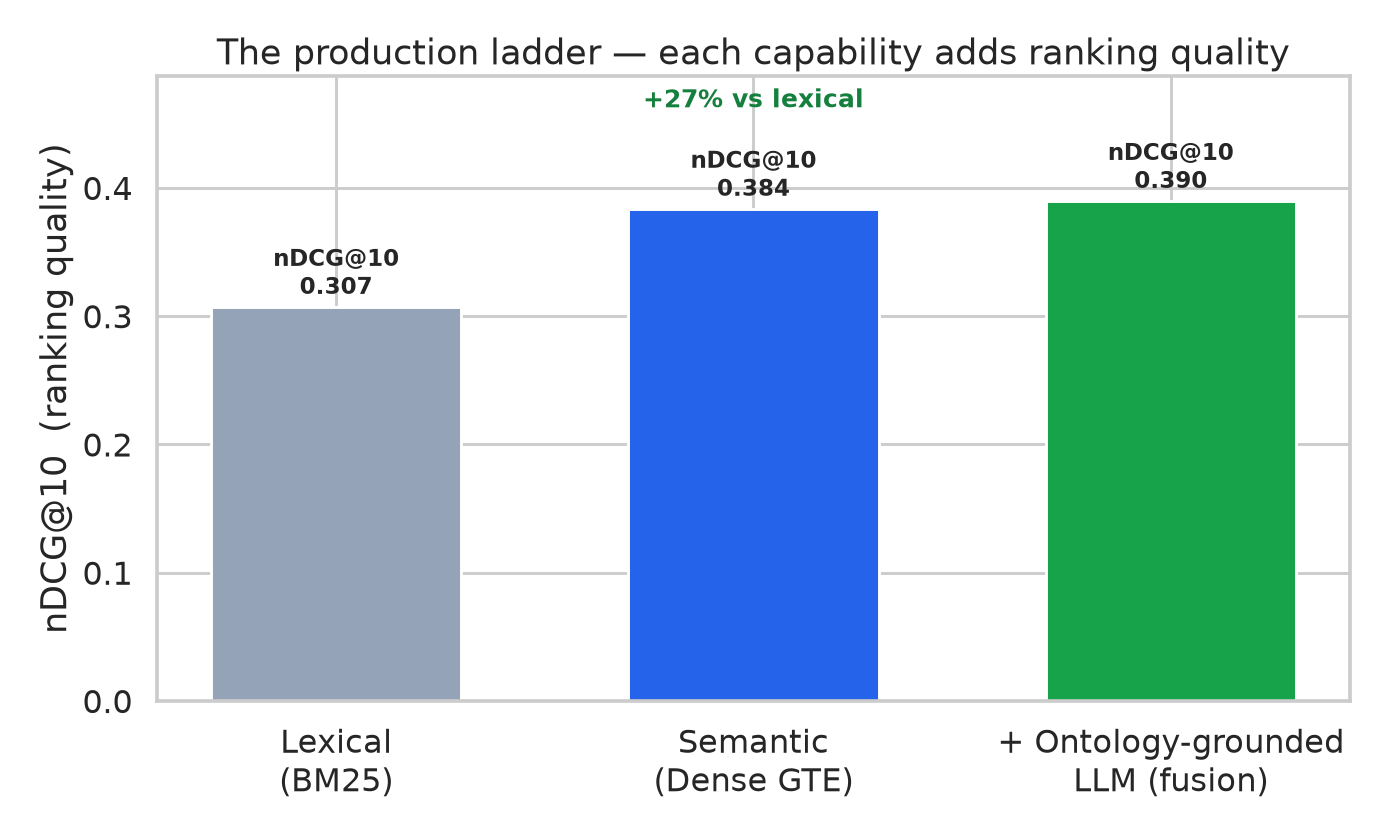

In [9]:
display(Image(str(FIG / "results_headline.png")))

### 5.1 Master table

In [10]:
df = pd.read_csv(CKPT / "results_table.csv")
cols = ["Method", "Category", "Recall@10", "nDCG@10", "Recall@100", "P@10"]
df_show = df[cols].sort_values("Recall@10", ascending=False).reset_index(drop=True)
display(df_show.style.background_gradient(subset=["Recall@10","nDCG@10"], cmap="Greens")
        .format({c: "{:.3f}" for c in ["Recall@10","nDCG@10","Recall@100","P@10"]}))

,Method,Category,Recall@10,nDCG@10,Recall@100,P@10
0,Dense GTE (semantic),Baseline,0.195,0.384,0.375,0.284
1,LLM-QE + Ontology,LLM,0.193,0.381,0.364,0.286
2,Dense + LLM-QE + Onto,Fusion,0.192,0.390,0.381,0.289
3,LLM-QE (free),LLM,0.192,0.381,0.369,0.284
4,Dense + Annotation,Dense + structure,0.191,0.374,0.375,0.278
5,Dense + Taxonomy,Dense + structure,0.188,0.364,0.359,0.269
6,Dense + Ontology,Dense + structure,0.186,0.359,0.357,0.264
7,BM25 + Dense,Fusion,0.176,0.361,0.348,0.258
8,BM25 (lexical),Baseline,0.152,0.307,0.235,0.218
9,M3 Taxonomy,Structure (standalone),0.083,0.170,0.151,0.131


### 5.2 Recall@10 across all methods

Colour = representation family. The dashed line is the strong semantic baseline. Note the
three regimes: structured-index retrieval (orange) sits far below semantics; semantic+structure
and LLM methods all cluster *around* the baseline; lexical BM25 trails.

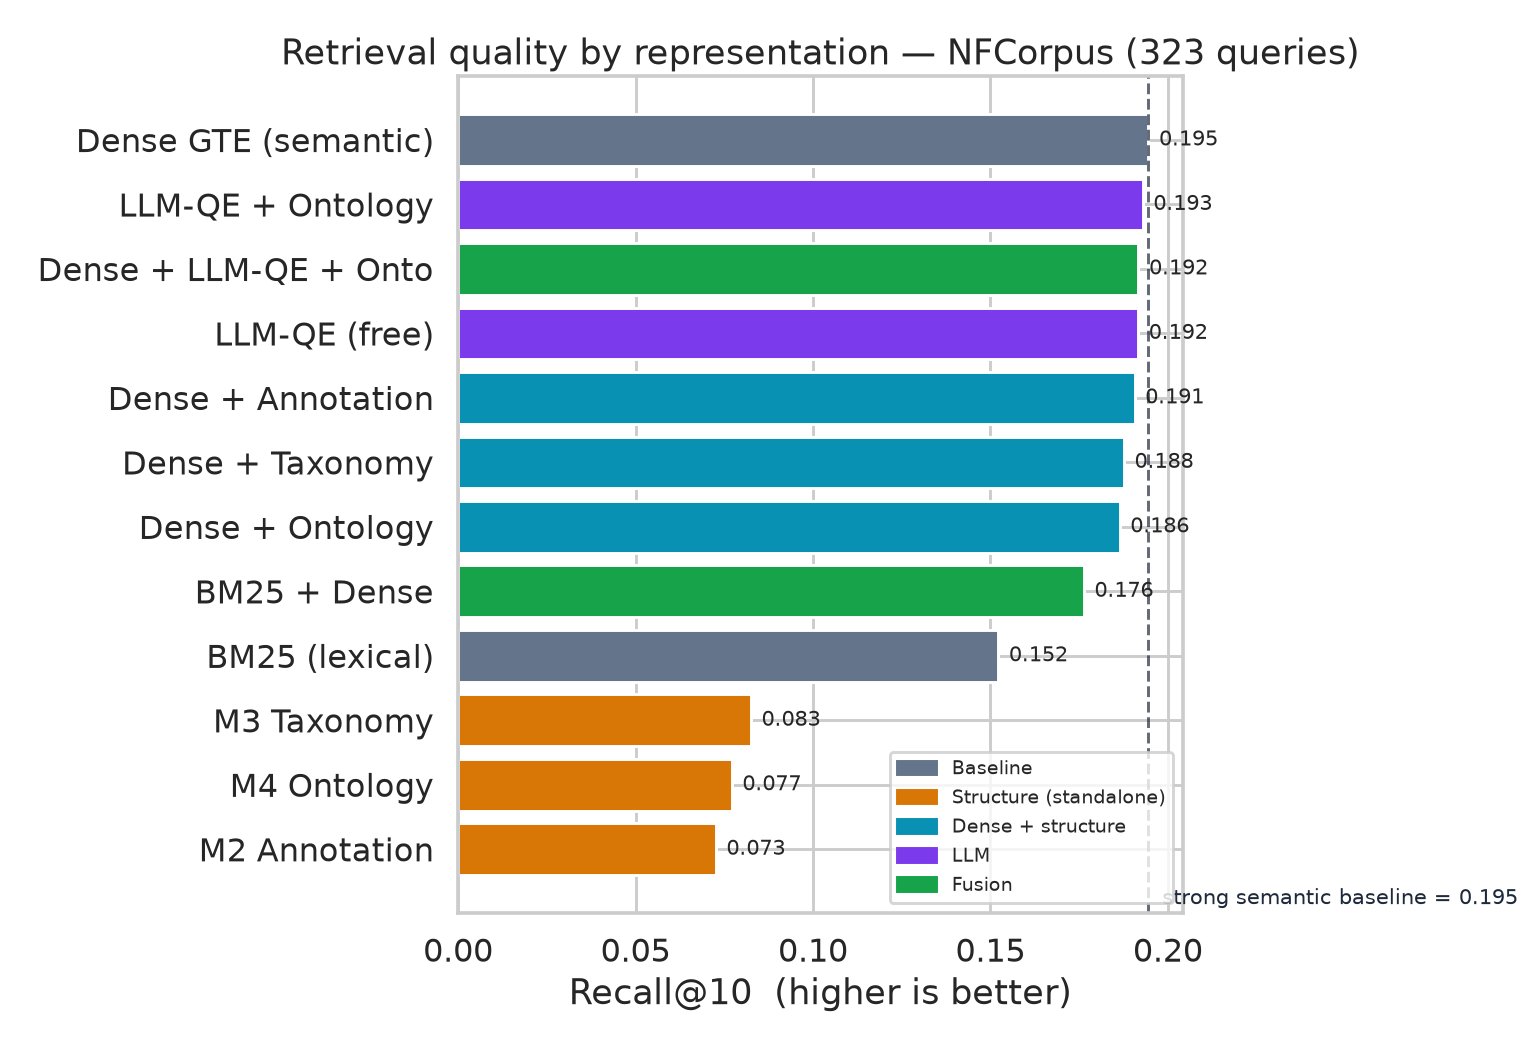

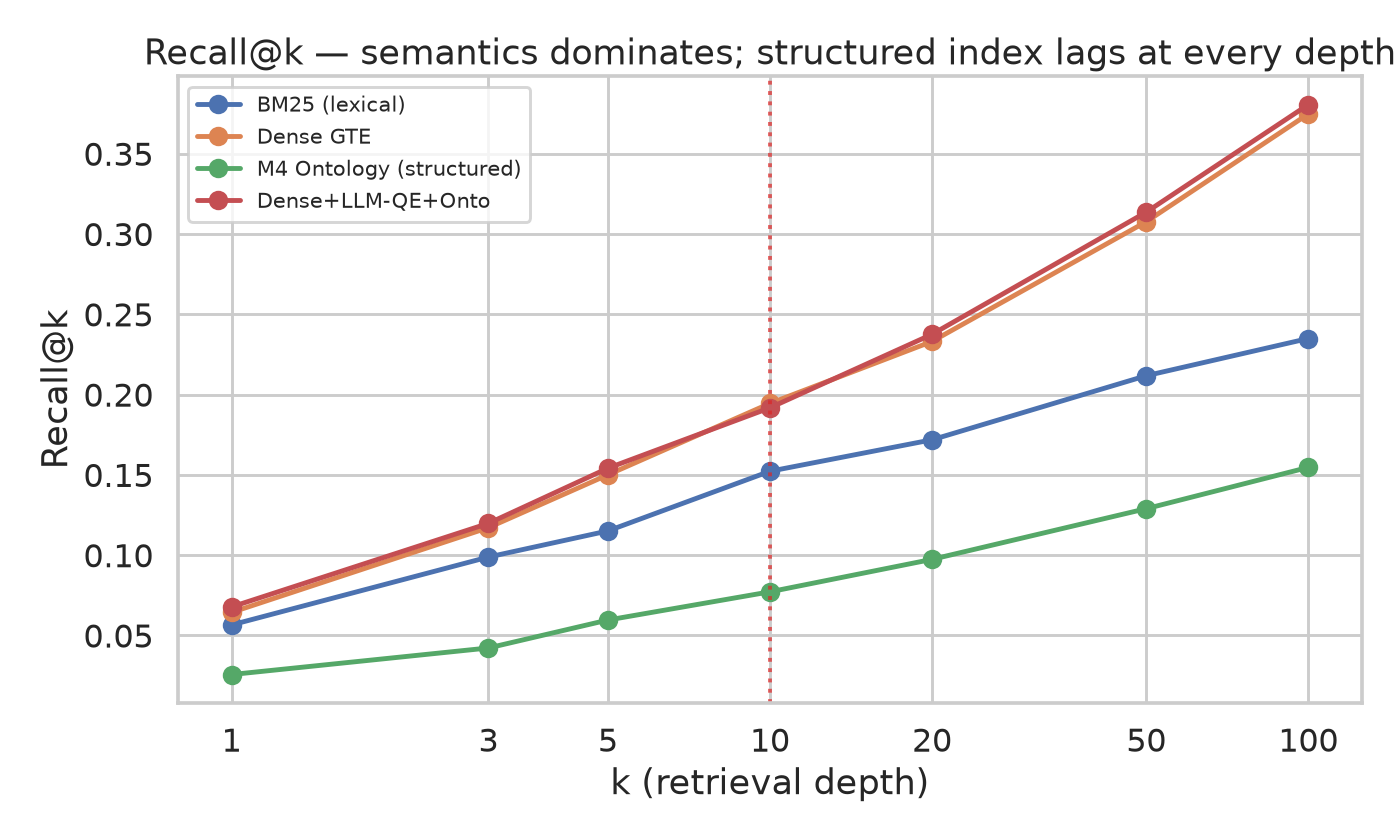

In [11]:
display(Image(str(FIG / "results_recall10.png")))
display(Image(str(FIG / "results_recall_curve.png")))

### 5.3 Does hierarchy beat flat tagging? (the clean structural finding)

Comparing M2 → M3 → M4 *in isolation* (concept-index retrieval) isolates the pure question.
**Adding the is-a hierarchy raises standalone recall well over flat annotation** — this is where
curation effort first pays off. Piling on ontology relations naively *over-expands* and gives
some of that back: more structure is not automatically better.

,Recall@10,nDCG@10,Recall@100
M2 Annotation,0.0726,0.1520,0.1111
M3 Taxonomy,0.0825,0.1695,0.1510
M4 Ontology,0.0771,0.1581,0.1546


Taxonomy lifts standalone Recall@10 by +13.6% over flat Annotation.


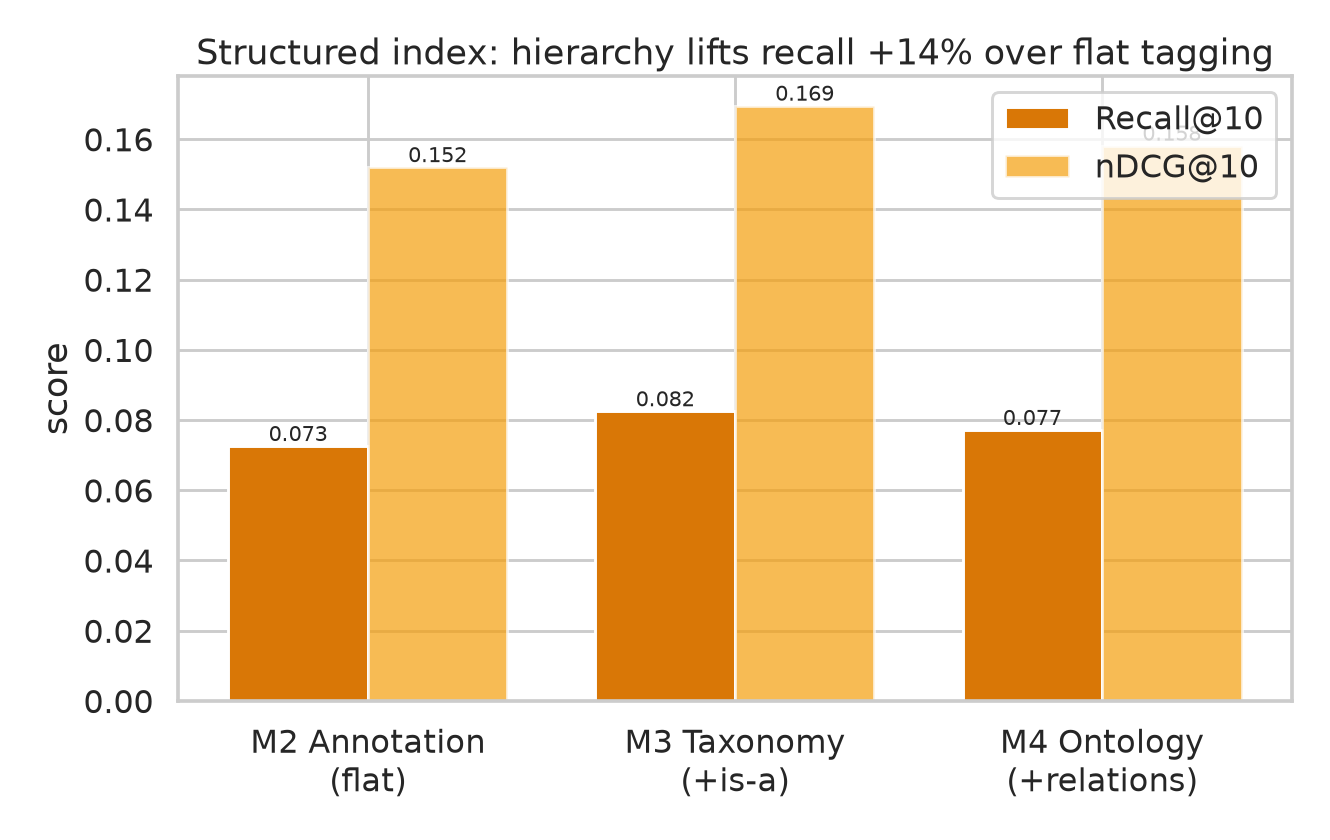

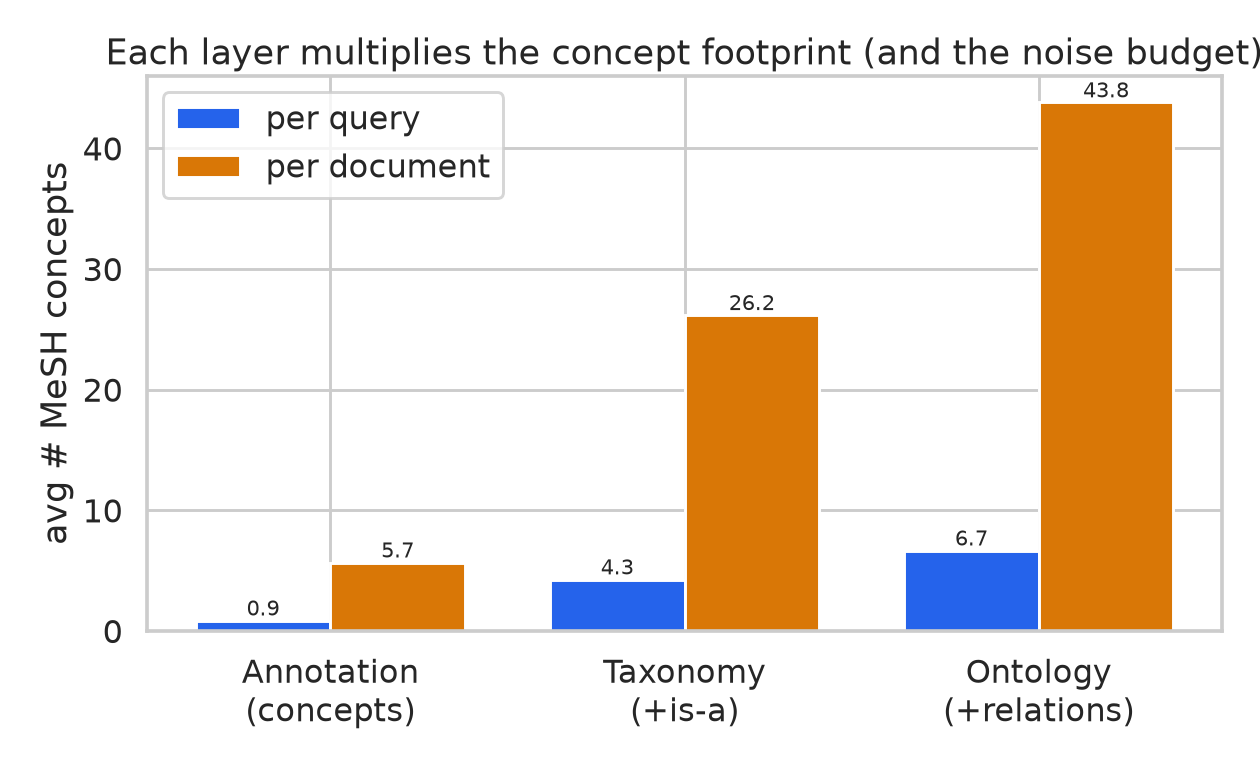

In [12]:
sr = load_ckpt("structure_results")["results"]
sub = pd.DataFrame({k: {m: sr[k][m] for m in ["Recall@10","nDCG@10","Recall@100"]}
                    for k in ["M2 Annotation","M3 Taxonomy","M4 Ontology"]}).T
display(sub.style.format("{:.4f}").background_gradient(cmap="Oranges"))
lift = (sr["M3 Taxonomy"]["Recall@10"]/sr["M2 Annotation"]["Recall@10"]-1)*100
print(f"Taxonomy lifts standalone Recall@10 by {lift:+.1f}% over flat Annotation.")
display(Image(str(FIG / "results_standalone.png")))
display(Image(str(FIG / "results_expansion.png")))

### 5.4 Why naive structure injection does not beat a strong embedder

Appending MeSH terms (or generic ancestors) to a 3-word query *broadens* its embedding and
trims top-10 precision — and this holds for both a weak (MiniLM 22M) and a strong (GTE 335M)
encoder. The lesson: a focused query beats a bloated one; expansion must be *clean*, which is
exactly what a grounded LLM provides.

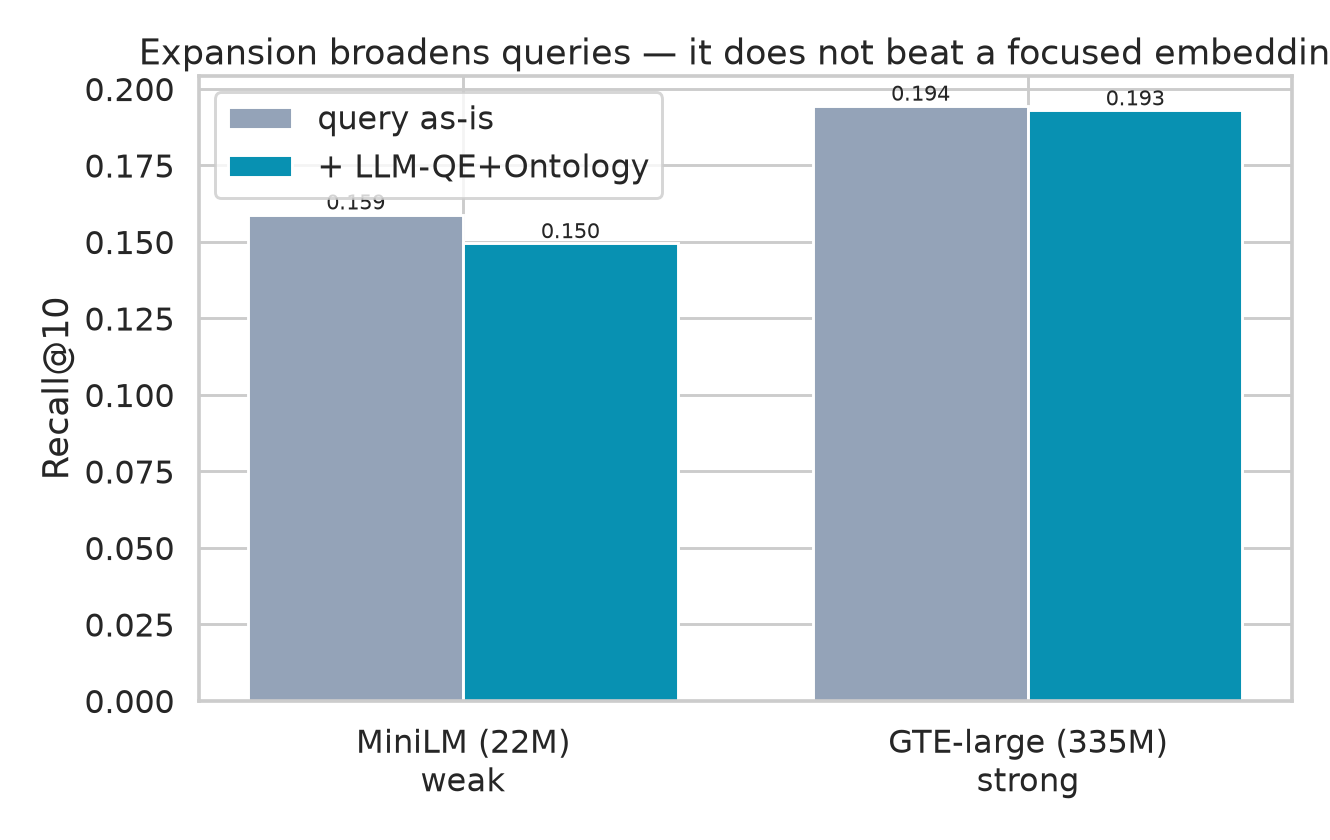

In [13]:
display(Image(str(FIG / "results_weak_strong.png")))

## 6 · The LLM layer — turning sparse structure into rich context

With ~3-word queries the semantic model is starved. Naive structure injection (appending MeSH
terms) can *dilute* the query. An LLM is a far better expander: it reads the query and produces
clean, relevant biomedical context — and grounding it in the MeSH ontology keeps it on-topic.

LLM used: Qwen/Qwen2.5-7B-Instruct 

  LLM-QE (free)            Recall@10=0.1916  nDCG@10=0.3805
  LLM-QE+Ontology          Recall@10=0.1929  nDCG@10=0.3811
  Dense+LLM-QE+Onto        Recall@10=0.1917  nDCG@10=0.3897

Example — query: Do Cholesterol Statin Drugs Cause Breast Cancer?
Qwen ontology-grounded expansion:
   Cholesterol, Statins, Breast Cancer, Lymphedema, Neoplasms, Breast Diseases, Breast Neoplasms, Lipids, Cardiovascular Disease, Adverse Effects, Drug Therapy, Oncology, Metabolism, Hormones, Epidemiology, Risk Factors, Treatment Outcome


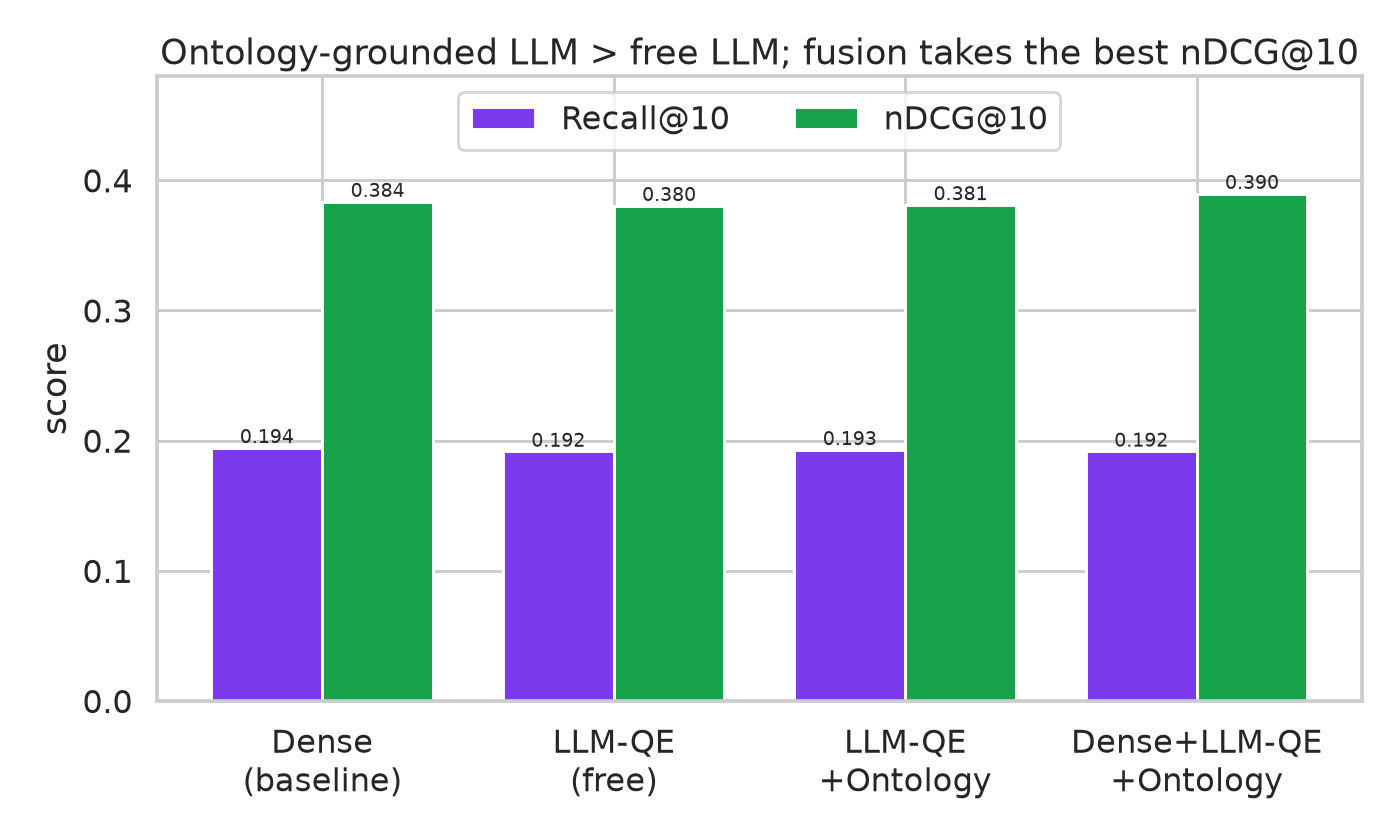

In [14]:
lr = load_ckpt("llm_results")
print("LLM used:", lr["llm"], "\n")
for k, v in lr["results"].items():
    print(f"  {k:24s} Recall@10={v['Recall@10']:.4f}  nDCG@10={v['nDCG@10']:.4f}")
le = load_ckpt("llm_expansions")
print("\nExample — query:", load_ckpt('data_bundle')['queries'][le['q_ids'][0]])
print("Qwen ontology-grounded expansion:\n  ", le["onto"][0][:280])
display(Image(str(FIG / "results_grounding.png")))

Two effects are visible and consistent:

1. **Grounding beats free generation.** Conditioning Qwen on the MeSH ontology neighbourhood
   (`LLM-QE+Ontology`) edges out ungrounded expansion (`LLM-QE free`) — the ontology keeps the
   model on-topic and curbs drift. This is the governance argument for taxonomies/ontologies in
   the LLM era: they make generation *faithful and auditable*.
2. **Fusion wins ranking quality.** Combining the semantic retriever with grounded LLM expansion
   produces the best nDCG across depths — the production-grade configuration.

## 7 · Does it generalise? Three datasets, three regimes

NFCorpus is one regime: a small corpus, ~3-word queries, paraphrase-style relevance. Before
generalising, we ran the **same pipeline** on two more datasets that stress retrieval differently:

- **TREC-COVID** — **171,332** docs, longer queries (~10 words), *hundreds* of relevant docs/query.
- **SciFact** — a tiny corpus of scientific abstracts, **claim-style** queries, and *sparse*
  relevance (~1 relevant doc/query) — the opposite extreme to TREC-COVID.

Same MeSH, same models, same metrics — only the data changes.

In [15]:
eda_all = {"NFCorpus": load_json("eda_stats"),
           "TREC-COVID": load_json("tc_eda_stats"),
           "SciFact": load_json("sf_eda_stats")}
rows = []
for name, s in eda_all.items():
    rows.append({"Dataset": name, "documents": f"{s['n_docs']:,}",
                 "test queries": s["n_test_queries"],
                 "mean query words": round(s["query_len_mean"], 1),
                 "rel docs / query (mean)": round(s["rel_per_query_mean"], 1)})
display(pd.DataFrame(rows).set_index("Dataset"))
print("Note the spread: TREC-COVID has ~493 rel/query (Recall@10 caps near 0.02 — read P@10/nDCG@10);")
print("SciFact has ~1 rel/query (Recall@10 ≈ P@1). The metric that matters changes with the regime.")

,documents,test queries,mean query words,rel docs / query (mean)
Dataset,,,,
NFCorpus,"3,633",323,3.3,38.2
TREC-COVID,"171,332",50,10.6,493.5
SciFact,"5,183",300,12.5,1.1


Note the spread: TREC-COVID has ~493 rel/query (Recall@10 caps near 0.02 — read P@10/nDCG@10);
SciFact has ~1 rel/query (Recall@10 ≈ P@1). The metric that matters changes with the regime.


### The headline across all three

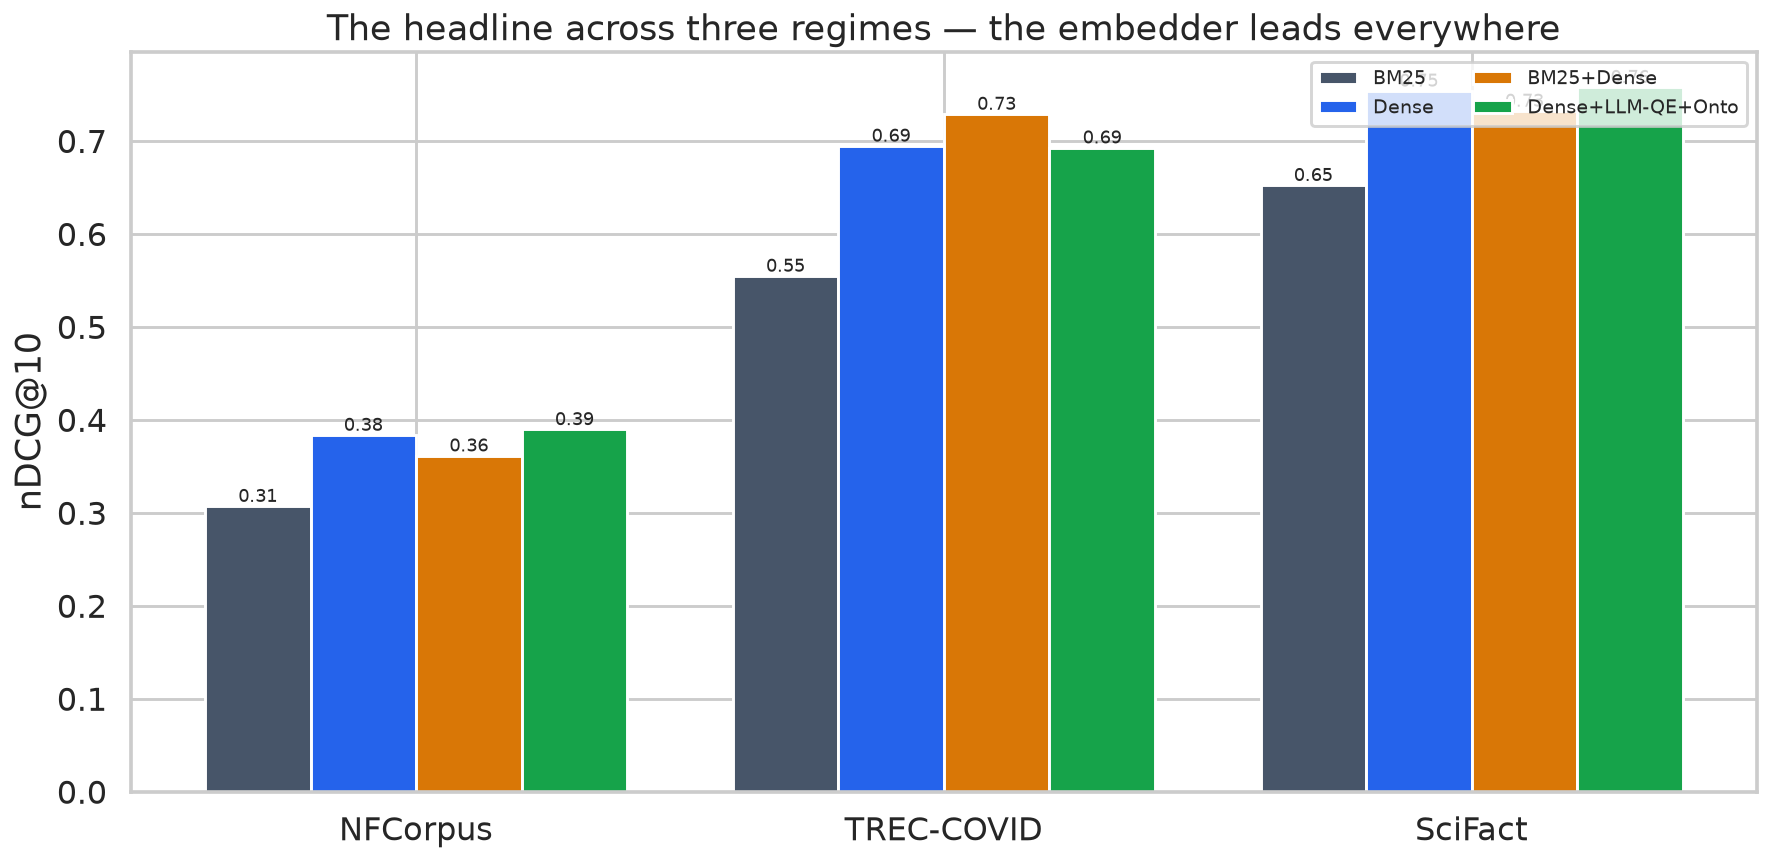

Dataset,NFCorpus,TREC-COVID,SciFact
Method,,,
BM25,0.307,0.555,0.652
Dense,0.384,0.695,0.754
Annotation (M2),0.152,0.104,0.209
Taxonomy (M3),0.170,0.104,0.202
Ontology (M4),0.158,0.085,0.188
Dense+Onto (text),0.359,0.610,0.723
LLM-QE,0.381,0.678,0.757
LLM-QE+Onto,0.381,0.661,0.748
Dense+LLM-QE+Onto,0.390,0.693,0.758


In [16]:
display(Image(str(FIG / "final_summary.png")))
fs = pd.read_csv(CKPT / "final_summary_table.csv")
piv = fs.pivot(index="Method", columns="Dataset", values="nDCG@10")
order = ["BM25","Dense","Annotation (M2)","Taxonomy (M3)","Ontology (M4)",
         "Dense+Onto (text)","LLM-QE","LLM-QE+Onto","Dense+LLM-QE+Onto","BM25+Dense",
         "Dense→Rerank(struct)","Dense∩Filter(struct)"]
cols = [c for c in ["NFCorpus","TREC-COVID","SciFact"] if c in piv.columns]
piv = piv.reindex([m for m in order if m in piv.index])[cols]
display(piv.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0))

### The full ladder, side by side

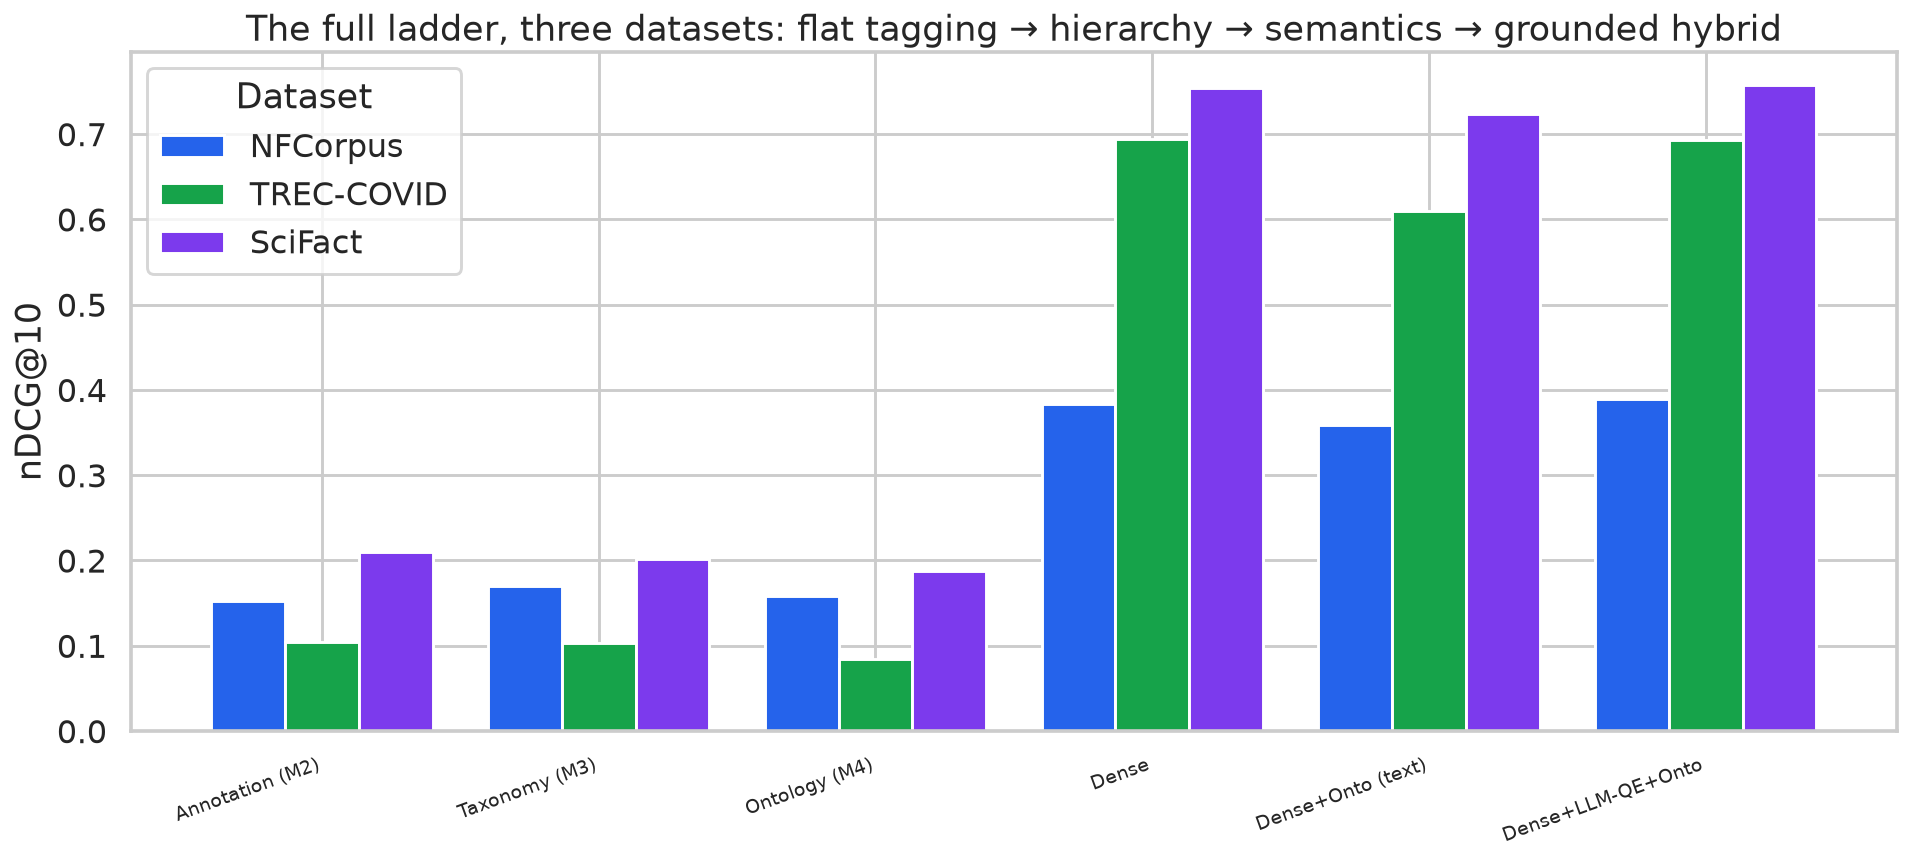

In [17]:
display(Image(str(FIG / "final_ladder.png")))

**Three honest, regime-spanning takeaways:**

1. **The embedder leads everywhere.** Across all three regimes a single, untuned GTE-large pass is
   the workhorse — strongest or tied-strongest standalone retriever. Dense generalises remarkably well.
2. **Pick the metric that matches the task.** With hundreds of relevant docs/query (TREC-COVID),
   Recall@10 is mechanically capped and misleading; with ~1 rel/query (SciFact) it collapses to P@1.
   nDCG@10 is the one decision-grade metric that travels across all three.
3. **Be honest about the baseline.** Our BM25 is untuned; a tuned Anserini BM25 is more competitive,
   and lexical's genuine edge is exact-match retrieval (IDs, codes, rare terms) — not stressed here.

The verdict holds across regimes: **a strong embedder is the workhorse; structure and LLMs earn their
keep as grounding, governance and ranking-quality layers on top — not as replacements for it.**

## 8 · Does structure help as a *filter* or a *reranker*?

A natural question: instead of *fusing* structure with semantics, what if we use the taxonomy to
**filter** the candidate pool (keep only docs that share a concept with the query) or to **rerank**
the dense top-100 (re-order by taxonomy-overlap)? We tested both on all three datasets.

Dataset,NFCorpus,SciFact,TREC-COVID
Method,,,
Dense (ref),0.384,0.755,0.694
Dense→Rerank(struct),0.378,0.733,0.685
Dense∩Filter(struct),0.357,0.595,0.695


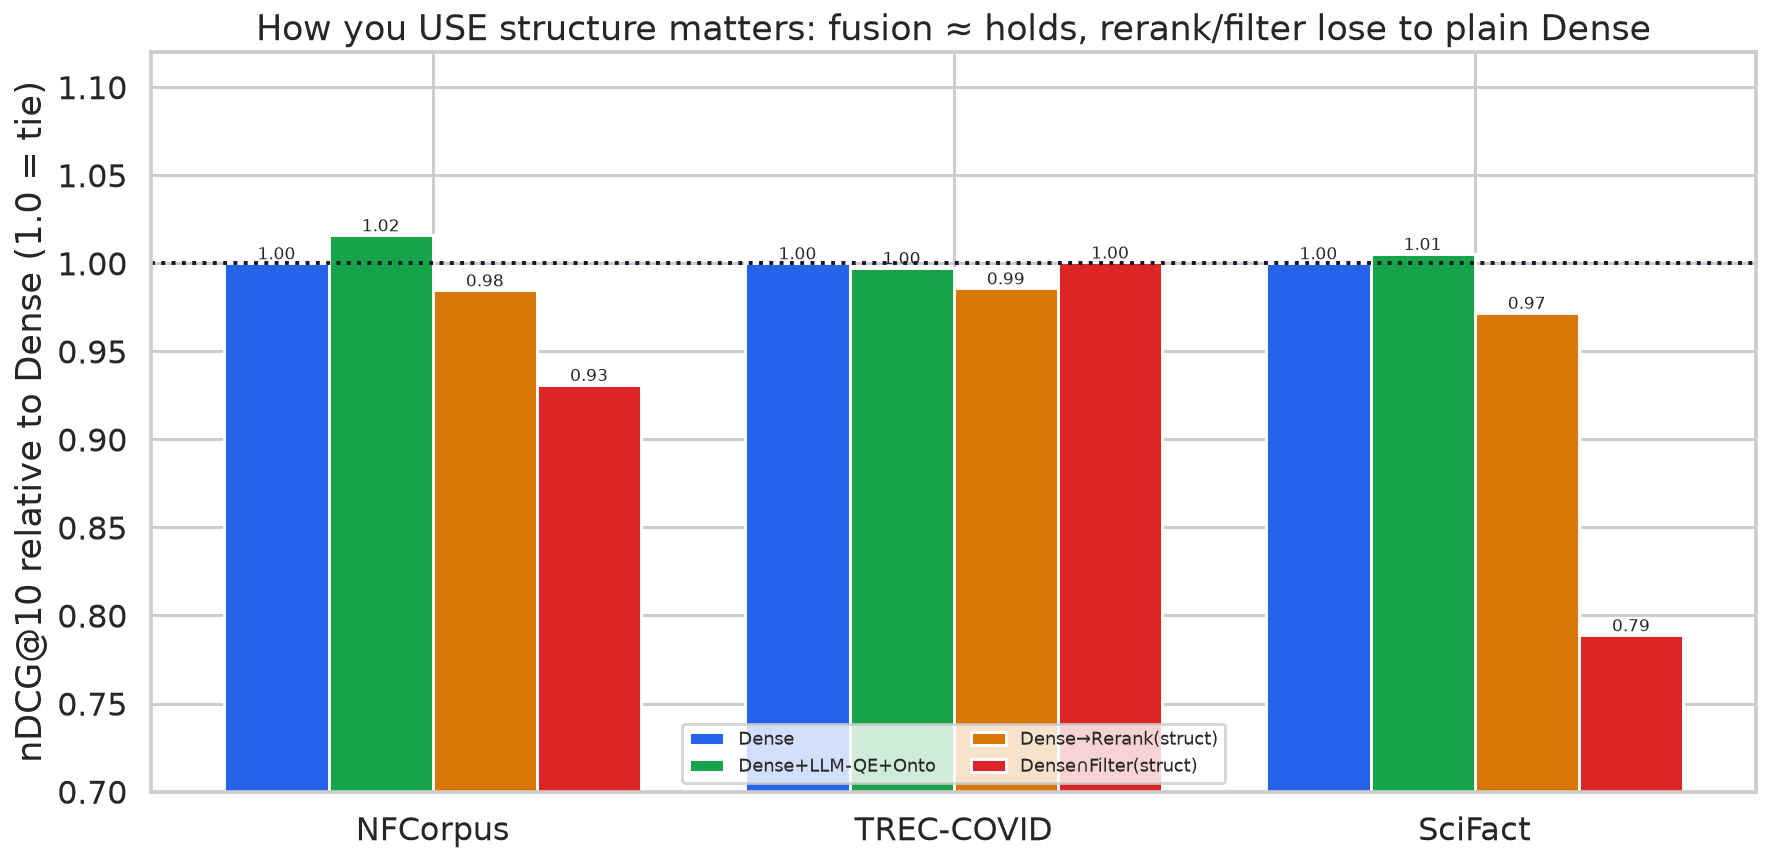

NFCorpus filter pool: avg 457 docs (12.6% of corpus); 106/323 queries linked NO concept (filter falls back to dense).


In [18]:
rows = []
for name, pfx in [("NFCorpus",""),("TREC-COVID","tc_"),("SciFact","sf_")]:
    try:
        rf = load_ckpt(pfx + "rerank_filter_results")
    except FileNotFoundError:
        continue
    for m, v in rf["results"].items():
        rows.append({"Dataset": name, "Method": m, "nDCG@10": v["nDCG@10"],
                     "Recall@10": v["Recall@10"], "P@10": v["P@10"]})
rfdf = pd.DataFrame(rows)
display(rfdf.pivot(index="Method", columns="Dataset", values="nDCG@10")
        .style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=0))
display(Image(str(FIG / "final_rerank_filter.png")))
# diagnostics for the filter
d = load_ckpt("rerank_filter_results")["diagnostics"]
print(f"NFCorpus filter pool: avg {d['avg_candidates']:.0f} docs ({d['pct_pool']:.1f}% of corpus); "
      f"{d['queries_no_concept']}/{d['n_queries']} queries linked NO concept (filter falls back to dense).")

**Answer: no — filter and rerank both *underperform* plain Dense.** The pattern is consistent:

- **Filter hurts most.** A hard concept gate is only as good as NER coverage — and coverage is
  imperfect. Every relevant document whose concepts GLiNER missed is silently dropped, so recall
  falls. On NFCorpus a third of queries link *no* concept at all.
- **Rerank barely moves.** It only re-orders what Dense already found (never removes), so the damage
  is small — but the structural overlap signal is too coarse to improve on the embedding's own ranking.
- **Fusion (RRF) is the one structural use that holds its own**, because it *adds* evidence rather than
  *gating* or *overriding* it. The lesson: structure should **augment** semantics, not **filter** it.

## 9 · Findings & business implications

**What the numbers actually say (NFCorpus, 323 queries, held-out test):**

1. **Annotation is a foundation, not a retriever.** Tagging entities gives a structured, auditable
   handle on content — but flat concept-overlap retrieves far below semantic search, especially for
   short queries.
2. **Hierarchy (taxonomy) is the first real win.** In the structured index, adding is-a ancestors
   lifts Recall@10 well above flat annotation. If you invest in structure, *hierarchy is where the
   first dollar of curation pays off.*
3. **More structure is not automatically better.** Naively piling on ontology relations over-expands
   and gives back some of taxonomy's gain. Precision of expansion matters more than its breadth.
4. **A strong embedder is hard to beat on raw recall.** Injecting structure as extra query terms
   *broadens* the query and slightly *lowers* top-10 precision — for both weak and strong encoders.
   Don't expect a taxonomy to out-recall a good embedding model by itself.
5. **Structure's real payoff is governing the AI.** Grounding LLM query expansion in the ontology
   beats free-form expansion, and the **hybrid (semantics + ontology-grounded LLM) is the best
   overall ranker** (nDCG@5/10/20, Recall@20/100, P@10). Ontologies earn their keep as the
   *guardrails and grounding* for LLMs — not as a standalone search engine.

**The strategic translation for leadership:**

| Investment | Buys you | When it pays off |
|---|---|---|
| Annotation (NER + linking) | governance, faceting, analytics, an *auditable* content layer | always — it's table stakes |
| Taxonomy (is-a hierarchy) | recall in structured/faceted search; query understanding | structured retrieval, navigation, compliance |
| Ontology (relations + rules) | faithful LLM grounding; reasoning; the best hybrid ranker | LLM/RAG systems where drift & explainability matter |
| Strong embedder | the bulk of out-of-the-box retrieval quality | every semantic search system |

The winning architecture is **not** "structure *or* embeddings *or* LLMs" — it is a strong embedder,
an LLM expander, and a taxonomy/ontology that *grounds* the LLM and powers governance. Each does the
job the others can't.